In [ ]:
import kagglehub

path = kagglehub.dataset_download("prevek18/ames-housing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
Path to dataset files: /kaggle/input/ames-housing-dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(path + "/AmesHousing.csv")


# Load data

In [ ]:
def load_data(df):
    df = pd.read_csv(path)
    return df


# Check the shape

In [ ]:
def shape(df):
   return df.shape
shape(df)

(2930, 82)

# Inspect data types

In [ ]:
def clean_us_info(df):
    print("Shape:", df.shape)

    print("Info before fixing types:")
    df.info()

    df["Neighborhood"] = df["Neighborhood"].astype("string").str.lower().str.strip()

    df["Exterior 1st"] = df["Exterior 1st"].astype("string").str.lower().str.strip()

    print("Info after fixing types:")
    df.info()

    print("Missing values:")
    print(df.isnull().sum().sort_values(ascending=False))
    return df

#  Find missing values:



 I chose this approach because it handles missing data without removing any rows. For categorical columns like Alley, filling with "None" shows clearly when a feature is absent. For numeric columns like Lot Frontage, using the median avoids distortion from extreme values and keeps the data balanced.

In [ ]:
def clean_missing_values(df):

    print("Missing values before cleaning:")
    print(df.isnull().sum().sum())
    df["Alley"] = df["Alley"].fillna("None")
    df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())
    print("Missing values after cleaning:")
    print(df.isnull().sum().sum())

    return df

# Handle duplicates



In [ ]:
def clean_duplicateds(df):
    before = df.shape[0]
    df = df.drop_duplicates()
    after = df.shape[0]
    print("Duplicates removed:", before - after)
    return df

#  Spot outliers & Handle outliers



In [ ]:
def plot_boxplot(df):
    df["SalePrice"].plot.box()
    plt.title("Boxplot of SalePrice")
    plt.show()

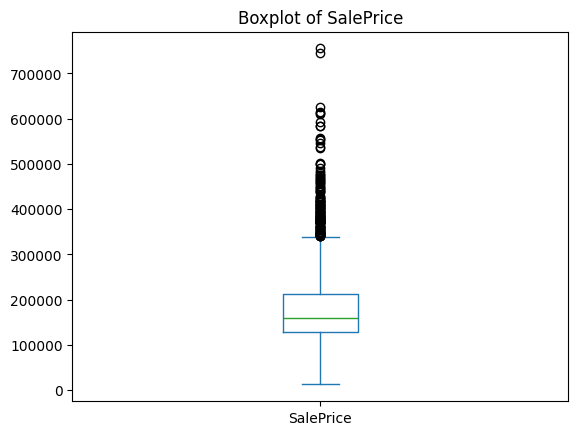

In [ ]:
plot_boxplot(df)

In [ ]:
def outliers(clean, column):
    cap = clean[column].quantile(0.99)
    clean[column] = clean[column].clip(upper=cap)
    return clean


# clean_data() function:



In [ ]:
def clean_data(path):
    df = load_data(path)
    clean_us_info(df)
    df = clean_missing_values(df)
    df = clean_duplicateds(df)
    df = outliers(df, "Gr Liv Area")
    run_all(df)
    plot_boxplot(df)
    return df


# checks

In [ ]:
assert df["SalePrice"].isnull().sum() == 0, "SalePrice still has missing values"
assert df["Lot Area"].isnull().sum() == 0, "Lot Area still has missing values"

assert (df["SalePrice"] > 0).all(), "Some SalePrice values are <= 0!"
assert df.duplicated().sum() == 0, "There are duplicate rows"


# run_all

In [ ]:
def run_all(clean):
    print("Shape:")
    print(df.shape)

    print("Info:")
    print(clean_us_info(df))

    print("Missing values:")
    print(clean_missing_values(df))

    print("\Duplicates:")
    print(clean_duplicateds(df))

    print("Outliers:")
    print(outliers(df, 'Gr Liv Area'))

run_all(df)

Shape:
(2930, 82)
Info:
Shape: (2930, 82)
Info before fixing types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   objec

<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_387/4176271839.py:11: SyntaxWarning: invalid escape sequence '\D'
  print("\Duplicates:")
